# **Data Exploration & Understanding**
Step 1: Initial Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('Ad_click_prediction_train.csv')
test_df = pd.read_csv('Ad_Click_prediciton_test.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              463291 non-null  int64  
 1   DateTime                463291 non-null  object 
 2   user_id                 463291 non-null  int64  
 3   product                 463291 non-null  object 
 4   campaign_id             463291 non-null  int64  
 5   webpage_id              463291 non-null  int64  
 6   product_category_1      463291 non-null  int64  
 7   product_category_2      97437 non-null   float64
 8   user_group_id           445048 non-null  float64
 9   gender                  445048 non-null  object 
 10  age_level               445048 non-null  float64
 11  user_depth              445048 non-null  float64
 12  city_development_index  338162 non-null  float64
 13  var_1                   463291 non-null  int64  
 14  is_click            

Step 2: Exploratory Data Analysis (EDA)

In [ ]:
# Click Through Rate

#Calculate Total Clicks (sum of all 1s in the binary column)
Total_Click = df['is_click'].sum()

#Calculate Total Impressions (total number of rows)
Total_Impression = len(df)

#Calculate CTR
CTR = (Total_Click / Total_Impression)*100
print("Click Through Rate:", CTR)

Click Through Rate: 6.762704218299081


In [ ]:
# Calculate the value counts and normalize them to get percentages
target_distribution = df['is_click'].value_counts(normalize=True) * 100

print("### Target Variable Distribution ###")
print(target_distribution)

### Target Variable Distribution ###
is_click
0    93.237296
1     6.762704
Name: proportion, dtype: float64


From the above, we observed that, the Dataset is Severaly Imbalanced and it required the Resampling Techniques.

In [ ]:
# Convert the 'DateTime' column to datetime objects
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['DateTime'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 463291 entries, 0 to 463290
Series name: DateTime
Non-Null Count   Dtype         
--------------   -----         
463291 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.5 MB


In [ ]:
# Create a new feature column for the hour (0=Midnight, 23=11 PM)
df['hour_of_day'] = df['DateTime'].dt.hour

# Group by the hour and calculate the mean of 'is_click'
# Multiply by 100 to get the percentage and sort to find the highest
hourly_ctr = (
    df.groupby('hour_of_day')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

# Rename the resulting Series for a clean output
hourly_ctr.name = 'CTR_Percentage'
hourly_ctr.head()

,CTR_Percentage
hour_of_day,
1,7.460815
7,7.397823
6,7.282210
8,7.027111
9,7.010128


In [ ]:
# Extract the Day of Week (Monday=0, Sunday=6)
df['day_of_week'] = df['DateTime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Categorize: Weekend (5, 6 = Saturday, Sunday) or Weekday
df['day_category'] = df['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

# Group by the category and calculate the mean of 'is_click'
weekend_vs_weekday_ctr = df.groupby('day_category')['is_click'].mean().mul(100).sort_values(ascending=False)
weekend_vs_weekday_ctr.name = 'Weekend_Weekday_CTR_Percentage'

print(weekend_vs_weekday_ctr.to_frame())

              Weekend_Weekday_CTR_Percentage
day_category                                
Weekend                             7.326207
Weekday                             6.646784


In [ ]:
# we extract the month number (1 for January to 12 for December)
df['month'] = df['DateTime'].dt.month

# Group by month and calculate the mean of 'Is_click'
monthly_ctr = (
    df.groupby('month')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

# Rename the resulting Series for clarity
monthly_ctr.name = 'Monthly_CTR_Percentage'

print(monthly_ctr.to_frame())

       Monthly_CTR_Percentage
month                        
7                    6.762704


In [ ]:
# Group by the 'age_level' column and calculate the mean of 'is_click' (CTR)
# Multiply by 100 to convert the proportion to a percentage
age_level_ctr = (
    df.groupby('age_level')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

age_level_ctr.name = 'Age_Level_CTR_Percentage'
age_level_ctr

,Age_Level_CTR_Percentage
age_level,
0.0,8.496732
6.0,8.227619
1.0,7.480342
5.0,7.415337
2.0,7.091937
3.0,6.451573
4.0,5.872312


In [ ]:
# Calculate CTR per Gender group
# Group by 'Gender' and calculate the mean of 'is_click' (CTR)
# The mean of a binary column gives the proportion of '1's (Clicks)
gender_ctr = (
    df.groupby('gender')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

gender_ctr.name = 'Gender_CTR_Percentage'

# Print the results
print(gender_ctr.to_frame())


female_ctr = gender_ctr.loc['Female']
male_ctr = gender_ctr.loc['Male']
Gender_CTR_Differences = gender_ctr.loc['Male'] - gender_ctr.loc['Female']
print(f"\nGender CTR Differences: {Gender_CTR_Differences*100:.2f}%")

        Gender_CTR_Percentage
gender                       
Male                 6.794187
Female               6.444548

Gender CTR Differences: 34.96%


In [ ]:
user_group_ctr = (df.groupby('user_group_id')['is_click'].mean().mul(100).sort_values(ascending=False))
user_depth_ctr = (df.groupby('user_depth')['is_click'].mean().mul(100).sort_values(ascending=False))
city_dev_ctr = (df.groupby('city_development_index')['is_click'].mean().mul(100).sort_values(ascending=False))

print(user_group_ctr.head(10).to_frame())
print(user_depth_ctr.to_frame())
print(city_dev_ctr.to_frame())

               is_click
user_group_id          
12.0           8.888889
0.0            8.496732
6.0            7.830626
11.0           7.670551
1.0            7.514423
5.0            7.312747
2.0            7.124230
7.0            6.474314
3.0            6.466786
8.0            6.379560
            is_click
user_depth          
1.0         7.191636
3.0         6.755992
2.0         6.551713
                        is_click
city_development_index          
2.0                     6.983738
1.0                     6.699573
3.0                     6.569796
4.0                     6.534556


In [ ]:
campaign_ctr = (
    df.groupby('campaign_id')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
print(campaign_ctr.head(10).to_frame())

             is_click
campaign_id          
405490       9.130693
404347       7.753417
98970        7.682875
396664       7.262435
105960       6.834491
82320        6.377249
359520       5.861957
414149       5.833390
118601       5.336185
360936       4.521277


In [ ]:
product_ctr = (
    df.groupby('product')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
print(product_ctr.head(10).to_frame())

         is_click
product          
J        9.269953
D        7.181473
H        6.985234
C        6.914942
E        6.871154
I        6.402348
A        6.191930
B        5.507362
F        4.909376
G        4.620778


In [ ]:
webpage_ctr = (
    df.groupby('webpage_id')['is_click']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
print(webpage_ctr.head(10).to_frame())

            is_click
webpage_id          
60305       9.130693
53587       7.753417
6970        7.682875
51181       7.262435
11085       6.834491
1734        6.377249
45962       5.833390
13787       5.427291
28529       5.336185


# Phase 2: Feature Engineering

In [ ]:
df['time_of_day'] = np.select(
    [
        df['hour_of_day'].between(0, 5, inclusive='both'),
        df['hour_of_day'].between(6, 11, inclusive='both'),
        df['hour_of_day'].between(12, 17, inclusive='both'),
        df['hour_of_day'].between(18, 23, inclusive='both')
    ],
    [
        'Night',
        'Morning',
        'Afternoon',
        'Evening'
    ],
    default='Other' # Should not happen with 0-23
)

In [ ]:
# Show head and info
print(df[['DateTime','hour_of_day', 'day_of_week', 'month', 'is_weekend', 'time_of_day']].tail())

print(df[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'time_of_day']].info())

                  DateTime  hour_of_day  day_of_week  month  is_weekend  \
463286 2017-07-07 23:59:00           23            4      7           0   
463287 2017-07-07 23:59:00           23            4      7           0   
463288 2017-07-07 23:59:00           23            4      7           0   
463289 2017-07-07 23:59:00           23            4      7           0   
463290 2017-07-07 23:59:00           23            4      7           0   

       time_of_day  
463286     Evening  
463287     Evening  
463288     Evening  
463289     Evening  
463290     Evening  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   hour_of_day  463291 non-null  int32 
 1   day_of_week  463291 non-null  int32 
 2   month        463291 non-null  int32 
 3   is_weekend   463291 non-null  int64 
 4   time_of_day  463291 non-null  object
dtypes: int32(3), i

In [ ]:
import pandas as pd
import altair as alt

# Ensure 'DateTime' is in datetime format and required columns are present
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['hour_of_day'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek # Ensure day_of_week is created
df['day_of_month'] = df['DateTime'].dt.day


# 1. Calculate CTR by Hour
ctr_by_hour = df.groupby('hour_of_day')['is_click'].mean().reset_index()
ctr_by_hour.columns = ['hour_of_day', 'CTR']
ctr_by_hour['hour_of_day'] = ctr_by_hour['hour_of_day'].astype(str)

# 2. Calculate CTR by Day of Week
ctr_by_day_of_week = df.groupby('day_of_week')['is_click'].mean().reset_index()
ctr_by_day_of_week.columns = ['day_of_week', 'CTR']
day_mapping = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
ctr_by_day_of_week['day_name'] = ctr_by_day_of_week['day_of_week'].map(day_mapping)
# Define order for plotting
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 3. Calculate CTR by Day of Month
ctr_by_day_of_month = df.groupby('day_of_month')['is_click'].mean().reset_index()
ctr_by_day_of_month.columns = ['day_of_month', 'CTR']

# --- Visualization: CTR by Hour ---
chart_hour = alt.Chart(ctr_by_hour).mark_bar().encode(
    x=alt.X('hour_of_day', title='Hour of Day (0-23)'),
    y=alt.Y('CTR', title='Click-Through Rate (CTR)'),
    tooltip=['hour_of_day', alt.Tooltip('CTR', format='.4f')]
).properties(
    title='Click-Through Rate by Hour of Day'
).interactive()

chart_hour.show()

# --- Visualization: CTR by Day of Week ---
chart_day_of_week = alt.Chart(ctr_by_day_of_week).mark_bar().encode(
    x=alt.X('day_name', sort=day_order, title='Day of Week'),
    y=alt.Y('CTR', title='Click-Through Rate (CTR)'),
    tooltip=['day_name', alt.Tooltip('CTR', format='.4f')]
).properties(
    title='Click-Through Rate by Day of Week'
).interactive()

chart_day_of_week.show()

# --- Visualization: CTR by Day of Month ---
chart_day_of_month = alt.Chart(ctr_by_day_of_month).mark_line(point=True).encode(
    x=alt.X('day_of_month', title='Day of Month (1-31)'),
    y=alt.Y('CTR', title='Click-Through Rate (CTR)'),
    tooltip=['day_of_month', alt.Tooltip('CTR', format='.4f')]
).properties(
    title='Click-Through Rate by Day of Month'
).interactive()

chart_day_of_month.show()

# Display the aggregated data for hour, focusing on lunch hours (11-14)
print("CTR by Hour (Focus on lunch hours 11-14):")
print(ctr_by_hour[ctr_by_hour['hour_of_day'].isin(['11', '12', '13', '14'])])

# Display the aggregated data for day of week
print("\nCTR by Day of Week:")
print(ctr_by_day_of_week[['day_name', 'CTR']])

# Display the aggregated data for day of month (Focus on end of month 28-31)
print("\nCTR by Day of Month (Focus on end of month 20-31):")
print(ctr_by_day_of_month[ctr_by_day_of_month['day_of_month'] >= 20])

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

CTR by Hour (Focus on lunch hours 11-14):
   hour_of_day       CTR
11          11  0.069543
12          12  0.068585
13          13  0.066420
14          14  0.065304

CTR by Day of Week:
  day_name       CTR
0      Mon  0.074932
1      Tue  0.072888
2      Wed  0.060689
3      Thu  0.062057
4      Fri  0.061582
5      Sun  0.073262

CTR by Day of Month (Focus on end of month 20-31):
Empty DataFrame
Columns: [day_of_month, CTR]
Index: []


In [ ]:
import pandas as pd

# Columns involved in concatenation
interaction_cols = ['user_id', 'product', 'campaign_id', 'webpage_id', 'gender', 'age_level']

# --- Step 1: Handle Missing Values and Convert to String ---
# Fill NaN values in the component columns with 'MISSING' string
df[interaction_cols] = df[interaction_cols].fillna('MISSING')

# Convert all component columns to string type
for col in interaction_cols:
    df[col] = df[col].astype(str)

# --- Step 2: Create Interaction Features ---
# 1. user_product_interaction: user_id + product
df['user_product_interaction'] = df['user_id'] + '_' + df['product']

# 2. campaign_webpage: campaign_id + webpage_id
df['campaign_webpage'] = df['campaign_id'] + '_' + df['webpage_id']

# 3. gender_age: gender + age_level
df['gender_age'] = df['gender'] + '_' + df['age_level']


# --- Step 3: Show head and info ---
new_features = ['user_product_interaction', 'campaign_webpage', 'gender_age']
check_cols = interaction_cols + new_features

print("First 5 rows with the new Interaction Features:")
print(df[check_cols].head())

print("\nInformation on the new Interaction Features:")
print(df[new_features].info())

First 5 rows with the new Interaction Features:
   user_id product campaign_id webpage_id  gender age_level  \
0   858557       C      359520      13787  Female       4.0   
1   243253       C      105960      11085  Female       2.0   
2   243253       C      359520      13787  Female       2.0   
3  1097446       I      359520      13787    Male       3.0   
4   663656       C      405490      60305    Male       2.0   

  user_product_interaction campaign_webpage  gender_age  
0                 858557_C     359520_13787  Female_4.0  
1                 243253_C     105960_11085  Female_2.0  
2                 243253_C     359520_13787  Female_2.0  
3                1097446_I     359520_13787    Male_3.0  
4                 663656_C     405490_60305    Male_2.0  

Information on the new Interaction Features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 3 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------   

In [ ]:
import pandas as pd
import altair as alt

def visualize_top_ctr(df, col_name, title_suffix):
    """Calculates CTR for the top 10 most frequent categories and generates a sorted bar chart."""

    # Identify the top 10 most frequent categories
    top_categories = df[col_name].value_counts().nlargest(10).index

    # Filter and calculate CTR
    df_filtered = df[df[col_name].isin(top_categories)]
    ctr_analysis = df_filtered.groupby(col_name)['is_click'].mean().reset_index()
    ctr_analysis.columns = [col_name, 'CTR']

    # Create Altair bar chart, sorting by CTR descending
    chart = alt.Chart(ctr_analysis).mark_bar().encode(
        x=alt.X('CTR', title='Click-Through Rate (CTR)', axis=alt.Axis(format='.2%')),
        y=alt.Y(col_name, sort='-x', title=col_name.replace('_', ' ').title()),
        color=alt.Color(col_name, legend=None),
        tooltip=[col_name, alt.Tooltip('CTR', format='.4f')]
    ).properties(
        title=f'CTR for Top 10 Most Frequent {title_suffix} Combinations'
    ).interactive()

    filename = f'ctr_by_top10_{col_name}.json'
    chart.show()
    return filename

# --- 1. Visualize user_product_interaction (High Affinity) ---
user_product_filename = visualize_top_ctr(df, 'user_product_interaction', 'User-Product')
print(f"Generated chart: {user_product_filename}")

# --- 2. Visualize campaign_webpage (Effectiveness by Placement) ---
campaign_webpage_filename = visualize_top_ctr(df, 'campaign_webpage', 'Campaign-Webpage')
print(f"Generated chart: {campaign_webpage_filename}")

alt.Chart(...)

Generated chart: ctr_by_top10_user_product_interaction.json


alt.Chart(...)

Generated chart: ctr_by_top10_campaign_webpage.json


In [ ]:
# --- 1. Calculate Aggregations at the User Level ---
user_agg = df.groupby('user_id').agg(
    # How many ads has this user seen? (Count of rows per user)
    user_total_views=('is_click', 'count'),
    # How many times has this user clicked? (Sum of is_click)
    user_total_clicks=('is_click', 'sum'),
    # Number of unique sessions per user
    user_sessions=('session_id', 'nunique')
).reset_index()

# --- 2. Calculate User's personal click-through rate (user_ctr) ---
user_agg['user_ctr'] = user_agg['user_total_clicks'] / user_agg['user_total_views']

# --- 3. Merge the new features back onto the original DataFrame ---
df_new = df.merge(user_agg, on='user_id', how='left')

# --- 4. Display head and info ---
new_features = ['user_total_views', 'user_total_clicks', 'user_ctr', 'user_sessions']
check_cols = ['user_id', 'is_click'] + new_features

print("First 5 rows with the new User-Level Aggregated Features:")
print(df_new[check_cols].head())

print("\nInformation on the new Aggregated Features:")
print(df_new[new_features].info())

First 5 rows with the new User-Level Aggregated Features:
   user_id  is_click  user_total_views  user_total_clicks  user_ctr  \
0   858557         0                 2                  0  0.000000   
1   243253         0                 3                  0  0.000000   
2   243253         0                 3                  0  0.000000   
3  1097446         0                18                  0  0.000000   
4   663656         0                11                  2  0.181818   

   user_sessions  
0              2  
1              3  
2              3  
3             18  
4             11  

Information on the new Aggregated Features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_total_views   463291 non-null  int64  
 1   user_total_clicks  463291 non-null  int64  
 2   user_ctr           463291 non-null  float64
 

In [ ]:
# --- 1. Calculate Product-Level Aggregations ---
product_agg = df.groupby('product')['is_click'].agg(
    product_views='count',
    product_ctr='mean'
).reset_index()

# --- 2. Calculate Campaign-Level Aggregations ---
campaign_agg = df.groupby('campaign_id')['is_click'].agg(
    campaign_views='count',
    campaign_ctr='mean'
).reset_index()

# --- 3. Merge Aggregated Features back to the original DataFrame ---
df_new = df.merge(product_agg, on='product', how='left')
df_new = df_new.merge(campaign_agg, on='campaign_id', how='left')

# --- 4. Display head and info ---
new_features = ['product_views', 'product_ctr', 'campaign_views', 'campaign_ctr']
check_cols = ['product', 'campaign_id', 'is_click'] + new_features

print("First 5 rows with the new Product and Campaign Aggregated Features:")
print(df_new[check_cols].head())

print("\nInformation on the new Aggregated Features:")
print(df_new[new_features].info())


First 5 rows with the new Product and Campaign Aggregated Features:
  product campaign_id  is_click  product_views  product_ctr  campaign_views  \
0       C      359520         0         163501     0.069149          108155   
1       C      105960         0         163501     0.069149           25781   
2       C      359520         0         163501     0.069149          108155   
3       I      359520         0          63711     0.064023          108155   
4       C      405490         0         163501     0.069149           95973   

   campaign_ctr  
0      0.058620  
1      0.068345  
2      0.058620  
3      0.058620  
4      0.091307  

Information on the new Aggregated Features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   product_views   463291 non-null  int64  
 1   product_ctr     463291 non-null  float64
 2   campa

# Phase 3: Data Preprocessing

In [ ]:
# Drop the original DateTime and session_id as they are not used directly in imputation
df = df.drop(columns=['DateTime', 'session_id','user_id'])

# Display initial info to identify missing values and data types
print("Initial DataFrame Info:")
df.info()

print("\nMissing values count before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   product                   463291 non-null  object 
 1   campaign_id               463291 non-null  object 
 2   webpage_id                463291 non-null  object 
 3   product_category_1        463291 non-null  int64  
 4   product_category_2        97437 non-null   float64
 5   user_group_id             445048 non-null  float64
 6   gender                    463291 non-null  object 
 7   age_level                 463291 non-null  object 
 8   user_depth                445048 non-null  float64
 9   city_development_index    338162 non-null  float64
 10  var_1                     463291 non-null  int64  
 11  is_click                  463291 non-null  int64  
 12  hour_of_day               463291 non-null  int32  
 13  day_of_week         

In [ ]:
import numpy as np

# 1. Identify columns for imputation
# Note: age_level is handled separately due to its previous string conversion
numerical_cols = ['product_category_2', 'user_group_id', 'user_depth', 'city_development_index']
categorical_cols = ['gender'] # 'gender' already has 'MISSING' as a string, no actual NaNs to fill currently

# Handle 'age_level' which was converted to string type but represents numerical data
if 'age_level' in df.columns:
    # Replace 'MISSING' string with NaN, then convert to numeric
    df['age_level'] = df['age_level'].replace('MISSING', np.nan)
    # Convert to float, coercing any other unconvertible values to NaN
    df['age_level'] = pd.to_numeric(df['age_level'], errors='coerce')
    # Add age_level back to numerical_cols for median imputation
    numerical_cols.append('age_level')

# 2. Impute Numerical Columns with Median
for col in numerical_cols:
    # Check if there are still NaNs in the column before calculating median
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val) # Removed inplace=True
        print(f"Filled NaN in '{col}' with Median: {median_val}")
    else:
        print(f"No NaN to fill in numerical column '{col}'.")


# 3. Impute Categorical Columns with Mode (only if there are actual NaNs)
for col in categorical_cols:
    if df[col].isnull().any(): # Check if there are NaNs to fill
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val) # Removed inplace=True
        print(f"Filled NaN in '{col}' with Mode: {mode_val}")
    else:
        print(f"No NaN to fill in categorical column '{col}'.")

# 4. Convert float columns representing discrete levels to integer after imputation
cols_to_convert_to_int = ['product_category_2', 'user_group_id', 'age_level', 'user_depth']
for col in cols_to_convert_to_int:
    # Ensure it's numeric before attempting to convert to int
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype(int)
    else:
        print(f"Column '{col}' is not numeric and cannot be converted to int.")

# 5. Verify imputation and save the cleaned data
print("\nMissing values count after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Filled NaN in 'product_category_2' with Median: 146115.0
Filled NaN in 'user_group_id' with Median: 3.0
Filled NaN in 'user_depth' with Median: 3.0
Filled NaN in 'city_development_index' with Median: 2.0
Filled NaN in 'age_level' with Median: 3.0
No NaN to fill in categorical column 'gender'.

Missing values count after imputation:
Series([], dtype: int64)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Re-load test_df to ensure it's clean for preprocessing
test_df = pd.read_csv('Ad_Click_prediciton_test.csv')

# --- Start of Preprocessing test_df to mirror df (as it is when X is created) ---

# 1. DateTime conversion and feature extraction for test_df
test_df['DateTime'] = pd.to_datetime(test_df['DateTime'])
test_df['hour_of_day'] = test_df['DateTime'].dt.hour
test_df['day_of_week'] = test_df['DateTime'].dt.dayofweek
test_df['is_weekend'] = test_df['day_of_week'].isin([5, 6]).astype(int)
test_df['day_category'] = test_df['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
test_df['month'] = test_df['DateTime'].dt.month
test_df['day_of_month'] = test_df['DateTime'].dt.day


test_df['time_of_day'] = np.select(
    [
        test_df['hour_of_day'].between(0, 5, inclusive='both'),
        test_df['hour_of_day'].between(6, 11, inclusive='both'),
        test_df['hour_of_day'].between(12, 17, inclusive='both'),
        test_df['hour_of_day'].between(18, 23, inclusive='both')
    ],
    [
        'Night',
        'Morning',
        'Afternoon',
        'Evening'
    ],
    default='Other'
)

# 2. Interaction features for test_df
interaction_cols = ['user_id', 'product', 'campaign_id', 'webpage_id', 'gender', 'age_level']

# Ensure 'MISSING' string is used as a placeholder consistent with training df
test_df[interaction_cols] = test_df[interaction_cols].fillna('MISSING')
for col in interaction_cols:
    test_df[col] = test_df[col].astype(str)

test_df['user_product_interaction'] = test_df['user_id'] + '_' + test_df['product']
test_df['campaign_webpage'] = test_df['campaign_id'] + '_' + test_df['webpage_id']
test_df['gender_age'] = test_df['gender'] + '_' + test_df['age_level']


# 3. Imputation for test_df (using medians/modes derived from the training 'df')
# These medians/modes should be extracted from the 'df' DataFrame after its imputation step (cell nMb8kvftHqqO)

# First, extract numeric equivalent for age_level from df to get its median
df_age_level_numeric_for_median = pd.to_numeric(df['age_level'].replace('MISSING', np.nan), errors='coerce')

median_product_category_2_df = df['product_category_2'].median()
median_user_group_id_df = df['user_group_id'].median()
median_user_depth_df = df['user_depth'].median()
median_city_development_index_df = df['city_development_index'].median()
median_age_level_df = df_age_level_numeric_for_median.median()

mode_gender_df = df['gender'].mode()[0]

# Handle 'age_level' in test_df specifically before numerical imputation
test_df['age_level'] = test_df['age_level'].replace('MISSING', np.nan)
test_df['age_level'] = pd.to_numeric(test_df['age_level'], errors='coerce')
test_df['age_level'] = test_df['age_level'].fillna(median_age_level_df) # Impute with median from df
test_df['age_level'] = test_df['age_level'].astype(int)

# Impute Numerical Columns with Median from df
test_df['product_category_2'] = test_df['product_category_2'].fillna(median_product_category_2_df)
test_df['user_group_id'] = test_df['user_group_id'].fillna(median_user_group_id_df)
test_df['user_depth'] = test_df['user_depth'].fillna(median_user_depth_df)
test_df['city_development_index'] = test_df['city_development_index'].fillna(median_city_development_index_df)

# Convert imputed numerical columns to int type if they are supposed to be discrete
test_df['product_category_2'] = test_df['product_category_2'].astype(int)
test_df['user_group_id'] = test_df['user_group_id'].astype(int)
test_df['user_depth'] = test_df['user_depth'].astype(int)

# Impute Categorical Columns with Mode from df (only 'gender' here)
test_df['gender'] = test_df['gender'].fillna(mode_gender_df)


# 4. Drop original columns for X_test_sub to match X
drop_cols_X_test = ['session_id', 'user_id', 'DateTime']
X_test_sub = test_df.drop(columns=drop_cols_X_test, errors='ignore')

# --- End of Preprocessing test_df to mirror df (as it is when X is created) ---


# The rest of the original code, with a modification to LabelEncoder fitting

X = df.drop(columns=['is_click'])
y = df['is_click']

# Ensure X_test_sub columns align with X *before* label encoding
X_train_original_cols = X.columns # Store original column names from X

# Add missing columns to X_test_sub and fill with 0
missing_in_test_set = set(X_train_original_cols) - set(X_test_sub.columns)
for c in missing_in_test_set:
    X_test_sub[c] = 0 # Assuming 0 is a safe default for newly added features or consistent with df's default

# Drop extra columns from X_test_sub
extra_in_test_set = set(X_test_sub.columns) - set(X_train_original_cols)
if extra_in_test_set:
    print(f"Warning: Columns in X_test_sub not in X: {extra_in_test_set}. Dropping them from X_test_sub.")
    X_test_sub = X_test_sub.drop(columns=list(extra_in_test_set))

# Ensure the order of columns is the same
X_test_sub = X_test_sub[X_train_original_cols]


# 1. Identify categorical columns (object type)
categorical_features = X.select_dtypes(include=['object']).columns

# 2. Apply Label Encoding to categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()

    # Combined unique values from both training (X) and test set (X_test_sub) for fitting
    # This addresses the 'unseen labels' ValueError
    all_categories = pd.concat([X[col], X_test_sub[col]], axis=0).unique()
    le.fit(all_categories) # Fit on all possible categories

    # Transform both X and X_test_sub
    X[col] = le.transform(X[col])
    X_test_sub[col] = le.transform(X_test_sub[col])
    label_encoders[col] = le


# 5. Train-Test Split (Stratified)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# X_test_sub scaling (after encoding)
X_test_scaled = scaler.transform(X_test_sub)

# Convert back to DataFrame for display/saving
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X.columns)

print("Processed Train Shape:", X_train_scaled_df.shape)
print("Processed Validation Shape:", X_val_scaled_df.shape)
print("Sample Scaled Data:")
print(X_train_scaled_df.head())

Processed Train Shape: (370632, 21)
Processed Validation Shape: (92659, 21)
Sample Scaled Data:
    product  campaign_id  webpage_id  product_category_1  product_category_2  \
0  1.352408    -1.239874   -0.234627            0.711161           -1.826430   
1  0.982223    -0.858588   -0.961517           -0.055088           -0.095608   
2  0.982223    -1.239874   -0.234627            1.477410           -1.826430   
3  1.352408    -1.239874   -0.234627            0.711161           -1.826430   
4 -0.128333     1.429128   -0.598072           -1.587586           -0.095608   

   user_group_id    gender  age_level  user_depth  city_development_index  \
0      -0.194444  0.406849   0.198832    0.296805                0.717733   
1      -0.194444  0.406849   0.198832    0.296805                0.717733   
2      -0.194444 -1.141842   0.198832    0.296805               -0.493986   
3      -0.194444  0.406849   0.198832    0.296805               -0.493986   
4      -1.038745  0.406849  -1.706770 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Re-load test_df to ensure it's clean for preprocessing
test_df = pd.read_csv('Ad_Click_prediciton_test.csv')

# --- Start of Preprocessing test_df to mirror df (as it is when X is created) ---

# 1. DateTime conversion and feature extraction for test_df
test_df['DateTime'] = pd.to_datetime(test_df['DateTime'])
test_df['hour_of_day'] = test_df['DateTime'].dt.hour
test_df['day_of_week'] = test_df['DateTime'].dt.dayofweek
test_df['is_weekend'] = test_df['day_of_week'].isin([5, 6]).astype(int)
test_df['day_category'] = test_df['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
test_df['month'] = test_df['DateTime'].dt.month
test_df['day_of_month'] = test_df['DateTime'].dt.day


test_df['time_of_day'] = np.select(
    [
        test_df['hour_of_day'].between(0, 5, inclusive='both'),
        test_df['hour_of_day'].between(6, 11, inclusive='both'),
        test_df['hour_of_day'].between(12, 17, inclusive='both'),
        test_df['hour_of_day'].between(18, 23, inclusive='both')
    ],
    [
        'Night',
        'Morning',
        'Afternoon',
        'Evening'
    ],
    default='Other'
)

# 2. Interaction features for test_df
interaction_cols = ['user_id', 'product', 'campaign_id', 'webpage_id', 'gender', 'age_level']

# Ensure 'MISSING' string is used as a placeholder consistent with training df
test_df[interaction_cols] = test_df[interaction_cols].fillna('MISSING')
for col in interaction_cols:
    test_df[col] = test_df[col].astype(str)

test_df['user_product_interaction'] = test_df['user_id'] + '_' + test_df['product']
test_df['campaign_webpage'] = test_df['campaign_id'] + '_' + test_df['webpage_id']
test_df['gender_age'] = test_df['gender'] + '_' + test_df['age_level']


# 3. Imputation for test_df (using medians/modes derived from the training 'df')
# These medians/modes should be extracted from the 'df' DataFrame after its imputation step (cell nMb8kvftHqqO)

# First, extract numeric equivalent for age_level from df to get its median
df_age_level_numeric_for_median = pd.to_numeric(df['age_level'].replace('MISSING', np.nan), errors='coerce')

median_product_category_2_df = df['product_category_2'].median()
median_user_group_id_df = df['user_group_id'].median()
median_user_depth_df = df['user_depth'].median()
median_city_development_index_df = df['city_development_index'].median()
median_age_level_df = df_age_level_numeric_for_median.median()

mode_gender_df = df['gender'].mode()[0]

# Handle 'age_level' in test_df specifically before numerical imputation
test_df['age_level'] = test_df['age_level'].replace('MISSING', np.nan)
test_df['age_level'] = pd.to_numeric(test_df['age_level'], errors='coerce')
test_df['age_level'] = test_df['age_level'].fillna(median_age_level_df) # Impute with median from df
test_df['age_level'] = test_df['age_level'].astype(int)

# Impute Numerical Columns with Median from df
test_df['product_category_2'] = test_df['product_category_2'].fillna(median_product_category_2_df)
test_df['user_group_id'] = test_df['user_group_id'].fillna(median_user_group_id_df)
test_df['user_depth'] = test_df['user_depth'].fillna(median_user_depth_df)
test_df['city_development_index'] = test_df['city_development_index'].fillna(median_city_development_index_df)

# Convert imputed numerical columns to int type if they are supposed to be discrete
test_df['product_category_2'] = test_df['product_category_2'].astype(int)
test_df['user_group_id'] = test_df['user_group_id'].astype(int)
test_df['user_depth'] = test_df['user_depth'].astype(int)

# Impute Categorical Columns with Mode from df (only 'gender' here)
test_df['gender'] = test_df['gender'].fillna(mode_gender_df)


# 4. Drop original columns for X_test_sub to match X
drop_cols_X_test = ['session_id', 'user_id', 'DateTime']
X_test_sub = test_df.drop(columns=drop_cols_X_test, errors='ignore')

# --- End of Preprocessing test_df to mirror df (as it is when X is created) ---


# The rest of the original code, with a modification to LabelEncoder fitting

X = df.drop(columns=['is_click'])
y = df['is_click']

# Ensure X_test_sub columns align with X *before* label encoding
X_train_original_cols = X.columns # Store original column names from X

# Add missing columns to X_test_sub and fill with 0
missing_in_test_set = set(X_train_original_cols) - set(X_test_sub.columns)
for c in missing_in_test_set:
    X_test_sub[c] = 0 # Assuming 0 is a safe default for newly added features or consistent with df's default

# Drop extra columns from X_test_sub
extra_in_test_set = set(X_test_sub.columns) - set(X_train_original_cols)
if extra_in_test_set:
    print(f"Warning: Columns in X_test_sub not in X: {extra_in_test_set}. Dropping them from X_test_sub.")
    X_test_sub = X_test_sub.drop(columns=list(extra_in_test_set))

# Ensure the order of columns is the same
X_test_sub = X_test_sub[X_train_original_cols]


# 1. Identify categorical columns (object type)
categorical_features = X.select_dtypes(include=['object']).columns

# 2. Apply Label Encoding to categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()

    # Combined unique values from both training (X) and test set (X_test_sub) for fitting
    # This addresses the 'unseen labels' ValueError
    all_categories = pd.concat([X[col], X_test_sub[col]], axis=0).unique()
    le.fit(all_categories) # Fit on all possible categories

    # Transform both X and X_test_sub
    X[col] = le.transform(X[col])
    X_test_sub[col] = le.transform(X_test_sub[col])
    label_encoders[col] = le


# 5. Train-Test Split (Stratified)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# X_test_sub scaling (after encoding)
X_test_scaled = scaler.transform(X_test_sub)

# Convert back to DataFrame for display/saving
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X.columns)

print("Processed Train Shape:", X_train_scaled_df.shape)
print("Processed Validation Shape:", X_val_scaled_df.shape)
print("Sample Scaled Data:")
print(X_train_scaled_df.head())

Processed Train Shape: (370632, 21)
Processed Validation Shape: (92659, 21)
Sample Scaled Data:
    product  campaign_id  webpage_id  product_category_1  product_category_2  \
0  1.352408    -1.239874   -0.234627            0.711161           -1.826430   
1  0.982223    -0.858588   -0.961517           -0.055088           -0.095608   
2  0.982223    -1.239874   -0.234627            1.477410           -1.826430   
3  1.352408    -1.239874   -0.234627            0.711161           -1.826430   
4 -0.128333     1.429128   -0.598072           -1.587586           -0.095608   

   user_group_id    gender  age_level  user_depth  city_development_index  \
0      -0.194444  0.406849   0.198832    0.296805                0.717733   
1      -0.194444  0.406849   0.198832    0.296805                0.717733   
2      -0.194444 -1.141842   0.198832    0.296805               -0.493986   
3      -0.194444  0.406849   0.198832    0.296805               -0.493986   
4      -1.038745  0.406849  -1.706770 

# Phase 4: Handling Class Imbalance

In [ ]:
# Check the class distribution in the target variable 'is_click'
target_counts = df['is_click'].value_counts()
target_percentages = df['is_click'].value_counts(normalize=True) * 100

print("Class Counts:")
print(target_counts)
print("\nClass Percentages:")
print(target_percentages)

# Calculate what accuracy would be if we just predicted '0' for everyone
null_accuracy = target_percentages[0]
print(f"\nNull Accuracy (Always predict 0): {null_accuracy:.2f}%")

Class Counts:
is_click
0    431960
1     31331
Name: count, dtype: int64

Class Percentages:
is_click
0    93.237296
1     6.762704
Name: proportion, dtype: float64

Null Accuracy (Always predict 0): 93.24%


# Phase 5: Model Building

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# --- RE-RUNNING PREPROCESSING (Ensure state is fresh) ---
train_df = pd.read_csv('Ad_click_prediction_train.csv')
# Feature Engineering
train_df['DateTime'] = pd.to_datetime(train_df['DateTime'])
train_df['hour'] = train_df['DateTime'].dt.hour
train_df['day_of_week'] = train_df['DateTime'].dt.dayofweek
train_df['day'] = train_df['DateTime'].dt.day
# Imputation
missing_cols = ['product_category_2', 'user_group_id', 'gender', 'age_level', 'user_depth', 'city_development_index']
for col in missing_cols:
    if train_df[col].dtype == 'object':
        train_df[col] = train_df[col].fillna('Missing')
    else:
        train_df[col] = train_df[col].fillna(-1)
# Encoding
le = LabelEncoder()
for col in ['product', 'gender']:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
# Drop & Split
X = train_df.drop(columns=['session_id', 'user_id', 'DateTime', 'is_click'])
y = train_df['is_click']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# --- MODEL SELECTION STRATEGY DEMO ---

# 1. Logistic Regression (Baseline)
# class_weight='balanced' helps with the 93/7 imbalance automatically
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_val_scaled)
y_prob_log = log_reg.predict_proba(X_val_scaled)[:, 1]

# 2. Random Forest (Ensemble)
# Reduced n_estimators and depth for speed in this demo
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_val_scaled)
y_prob_rf = rf_clf.predict_proba(X_val_scaled)[:, 1]

# --- EVALUATION ---
models = []

# Helper to log metrics
def log_metrics(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    return {'Model': name, 'Accuracy': acc, 'ROC-AUC': roc, 'F1 (Class 1)': f1}

models.append(log_metrics('Logistic Regression', y_val, y_pred_log, y_prob_log))
models.append(log_metrics('Random Forest', y_val, y_pred_rf, y_prob_rf))

results_df = pd.DataFrame(models)
print(results_df)
print("\n--- Logistic Regression Report ---")
print(classification_report(y_val, y_pred_log))
print("\n--- Random Forest Report ---")
print(classification_report(y_val, y_pred_rf))

                 Model  Accuracy   ROC-AUC  F1 (Class 1)
0  Logistic Regression  0.543930  0.559847      0.136461
1        Random Forest  0.658511  0.591787      0.152734

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.94      0.54      0.69     86393
           1       0.08      0.53      0.14      6266

    accuracy                           0.54     92659
   macro avg       0.51      0.54      0.41     92659
weighted avg       0.88      0.54      0.65     92659


--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     86393
           1       0.09      0.46      0.15      6266

    accuracy                           0.66     92659
   macro avg       0.52      0.56      0.47     92659
weighted avg       0.89      0.66      0.74     92659



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# --- RE-RUNNING PREPROCESSING (Ensure state is fresh) ---
train_df = pd.read_csv('Ad_click_prediction_train.csv')
# Feature Engineering
train_df['DateTime'] = pd.to_datetime(train_df['DateTime'])
train_df['hour'] = train_df['DateTime'].dt.hour
train_df['day_of_week'] = train_df['DateTime'].dt.dayofweek
train_df['day'] = train_df['DateTime'].dt.day
# Imputation
missing_cols = ['product_category_2', 'user_group_id', 'gender', 'age_level', 'user_depth', 'city_development_index']
for col in missing_cols:
    if train_df[col].dtype == 'object':
        train_df[col] = train_df[col].fillna('Missing')
    else:
        train_df[col] = train_df[col].fillna(-1)
# Encoding
le = LabelEncoder()
for col in ['product', 'gender']:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
# Drop & Split
X = train_df.drop(columns=['session_id', 'user_id', 'DateTime', 'is_click'])
y = train_df['is_click']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# --- MODEL SELECTION STRATEGY: Gradient Boosting ---
# Calculate imbalance ratio for sample_weight
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
ratio = neg_count / pos_count

# Generate sample weights: weight for class 1 is the ratio of class 0/class 1
sample_weights = np.ones(len(y_train))
sample_weights[y_train == 1] = ratio

# Gradient Boosting Classifier (GBC)
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_prob_gb = gb_clf.predict_proba(X_val_scaled)[:, 1]
y_pred_gb = gb_clf.predict(X_val_scaled)

# --- EVALUATION ---
# Helper to log metrics
def log_metrics(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    # Get precision and recall for class 1
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    return {'Model': name, 'Accuracy': acc, 'ROC-AUC': roc, 'Recall (Class 1)': recall, 'Precision (Class 1)': precision, 'F1-Score': f1}

# 1. Logistic Regression (Re-run for consistent comparison)
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_val_scaled)
y_prob_log = log_reg.predict_proba(X_val_scaled)[:, 1]

# 2. Random Forest (Re-run for consistent comparison)
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_val_scaled)
y_prob_rf = rf_clf.predict_proba(X_val_scaled)[:, 1]


models = []
models.append(log_metrics('Logistic Regression', y_val, y_pred_log, y_prob_log))
models.append(log_metrics('Random Forest', y_val, y_pred_rf, y_prob_rf))
models.append(log_metrics('Gradient Boosting', y_val, y_pred_gb, y_prob_gb))

results_df = pd.DataFrame(models).round(4)
print(results_df)

print("\n--- Gradient Boosting Classification Report ---")
print(classification_report(y_val, y_pred_gb))

                 Model  Accuracy  ROC-AUC  Recall (Class 1)  \
0  Logistic Regression    0.5439   0.5598            0.5329   
1        Random Forest    0.6585   0.5918            0.4552   
2    Gradient Boosting    0.6111   0.5930            0.5193   

   Precision (Class 1)  F1-Score  
0               0.0782    0.1365  
1               0.0918    0.1527  
2               0.0897    0.1530  

--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     86393
           1       0.09      0.52      0.15      6266

    accuracy                           0.61     92659
   macro avg       0.52      0.57      0.45     92659
weighted avg       0.89      0.61      0.71     92659



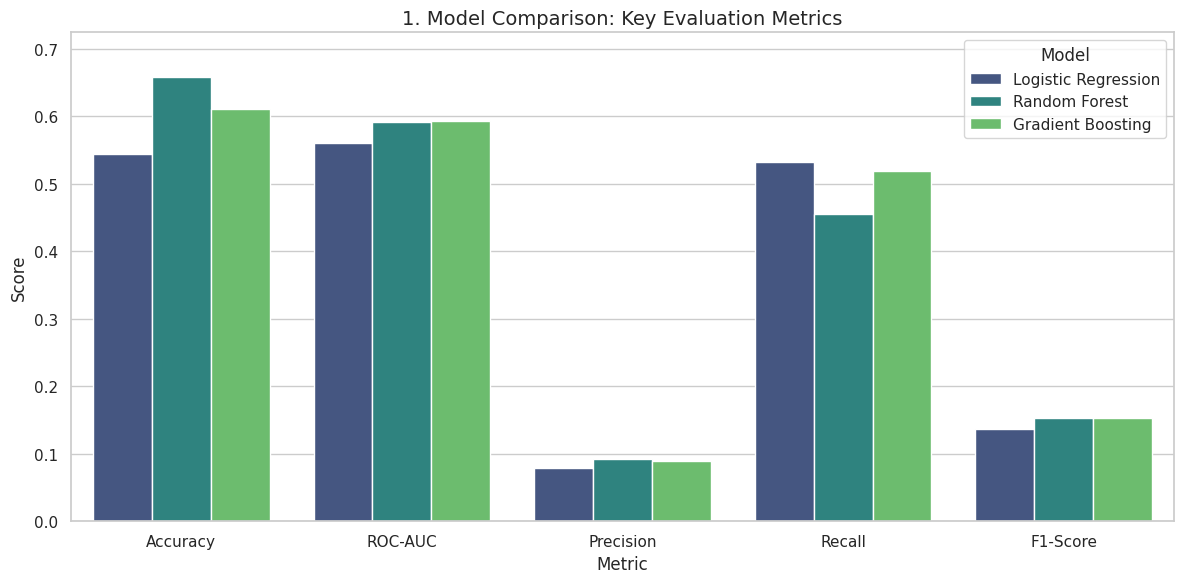

/tmp/ipython-input-2386437552.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='magma')


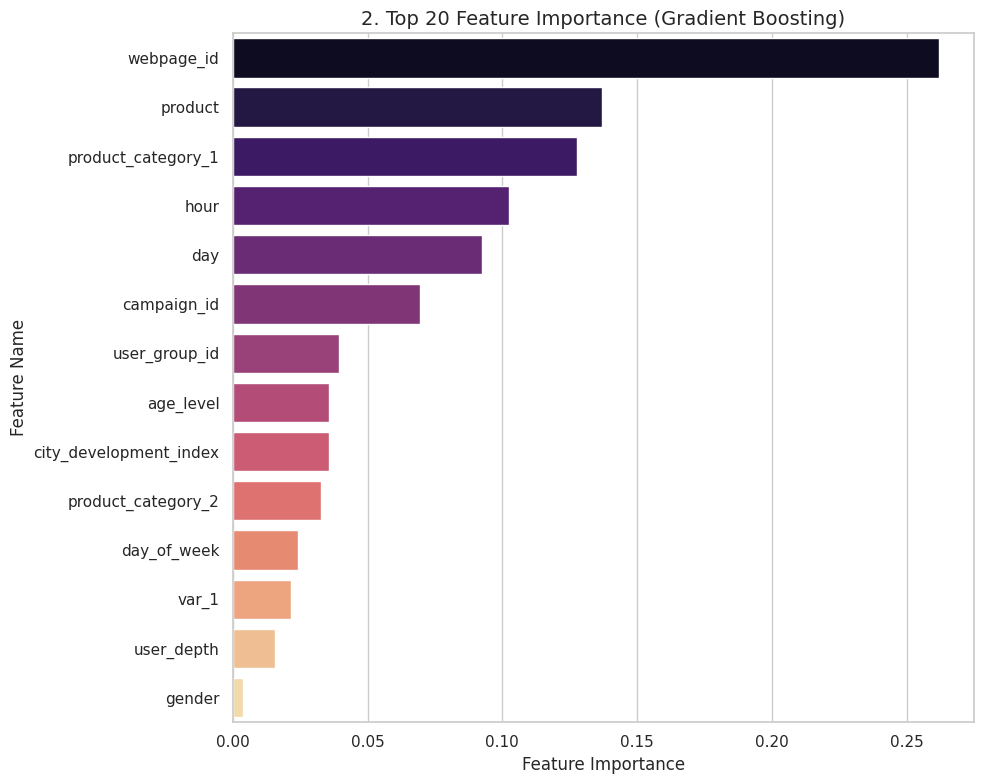

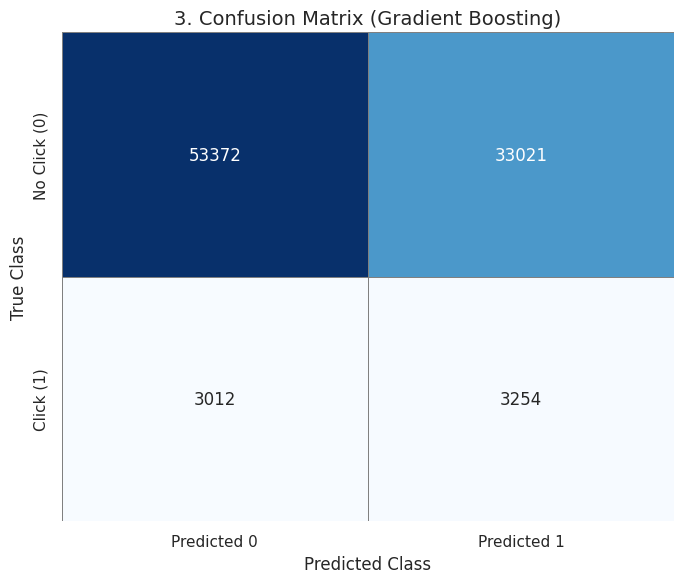

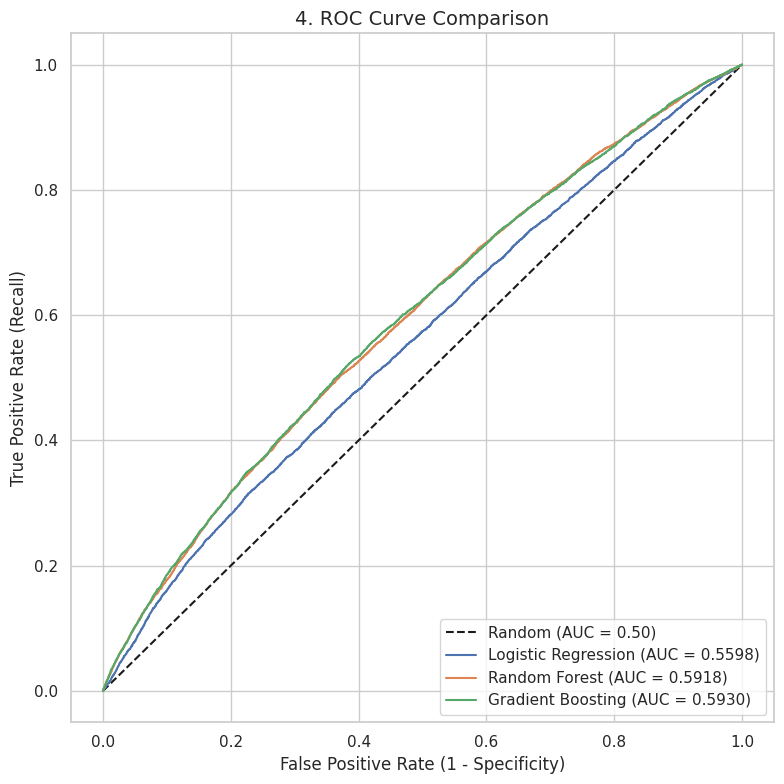

| Model               |   Accuracy |   ROC-AUC |   Precision |   Recall |   F1-Score |
|:--------------------|-----------:|----------:|------------:|---------:|-----------:|
| Logistic Regression |   0.54393  |  0.559847 |   0.0782499 | 0.532876 |   0.136461 |
| Random Forest       |   0.658511 |  0.591787 |   0.0917632 | 0.455155 |   0.152734 |
| Gradient Boosting   |   0.611123 |  0.593022 |   0.0897037 | 0.519311 |   0.152982 |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve

# Set plotting style
sns.set_theme(style="whitegrid")

# --- RE-RUNNING PREPROCESSING & TRAINING ---
train_df = pd.read_csv('Ad_click_prediction_train.csv')
# Feature Engineering
train_df['DateTime'] = pd.to_datetime(train_df['DateTime'])
train_df['hour'] = train_df['DateTime'].dt.hour
train_df['day_of_week'] = train_df['DateTime'].dt.dayofweek
train_df['day'] = train_df['DateTime'].dt.day
# Imputation
missing_cols = ['product_category_2', 'user_group_id', 'gender', 'age_level', 'user_depth', 'city_development_index']
for col in missing_cols:
    if train_df[col].dtype == 'object':
        train_df[col] = train_df[col].fillna('Missing')
    else:
        train_df[col] = train_df[col].fillna(-1)
# Encoding
le = LabelEncoder()
for col in ['product', 'gender']:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
# Drop & Split
X = train_df.drop(columns=['session_id', 'user_id', 'DateTime', 'is_click'])
y = train_df['is_click']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Calculate imbalance ratio for sample_weight
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
ratio = neg_count / pos_count
sample_weights = np.ones(len(y_train))
sample_weights[y_train == 1] = ratio

# Training models
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_val_scaled)
y_prob_log = log_reg.predict_proba(X_val_scaled)[:, 1]

rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_val_scaled)
y_prob_rf = rf_clf.predict_proba(X_val_scaled)[:, 1]

gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_prob_gb = gb_clf.predict_proba(X_val_scaled)[:, 1]
y_pred_gb = gb_clf.predict(X_val_scaled)

# Helper function to extract metrics
def get_metrics(name, y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score']
    }

models = []
models.append(get_metrics('Logistic Regression', y_val, y_pred_log, y_prob_log))
models.append(get_metrics('Random Forest', y_val, y_pred_rf, y_prob_rf))
models.append(get_metrics('Gradient Boosting', y_val, y_pred_gb, y_prob_gb))
results_df = pd.DataFrame(models)

# --- 1. Model Comparison Chart ---
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']
plot_df = results_df.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=plot_df, palette='viridis')
plt.title('1. Model Comparison: Key Evaluation Metrics', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, plot_df['Score'].max() * 1.1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
plt.close()

# --- 2. Feature Importance Plot (Using Gradient Boosting) ---
feature_importance = pd.Series(gb_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_20_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='magma')
plt.title('2. Top 20 Feature Importance (Gradient Boosting)', fontsize=14)
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()
plt.close()

# --- 3. Confusion Matrix (Using Gradient Boosting) ---
cm = confusion_matrix(y_val, y_pred_gb)
cm_df = pd.DataFrame(cm, index=['No Click (0)', 'Click (1)'], columns=['Predicted 0', 'Predicted 1'])

plt.figure(figsize=(7, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5, linecolor='gray')
plt.title('3. Confusion Matrix (Gradient Boosting)', fontsize=14)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()
plt.close()

# --- 4. ROC Curve ---
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

# Data for ROC curves
models_for_roc = {
    'Logistic Regression': (y_prob_log, roc_auc_score(y_val, y_prob_log)),
    'Random Forest': (y_prob_rf, roc_auc_score(y_val, y_prob_rf)),
    'Gradient Boosting': (y_prob_gb, roc_auc_score(y_val, y_prob_gb)),
}

for name, (y_prob, auc_score) in models_for_roc.items():
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('4. ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.close()

print(results_df.to_markdown(index=False))